In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [3]:
! ls /global/home/users/ann_scheliga/neuralhydrology/runs/

EXP00_1basin_cbr_no_sw_lossMSE_0508_102017
EXP00_1basin_cbr_wi_sw_lossMSE_0508_101940
EXP00_cbr_powell_no_sw_0708_145201
EXP00_cbr_powell_no_sw_MSE_0708_151647
EXP00_cbr_powell_wi_sw_0708_145113
EXP00_cbr_powell_wi_sw_MSE_0708_151608
EXP00_niger_kainji_no_sw_0708_144738
EXP00_niger_kainji_no_sw_MSE_0708_151522
EXP00_niger_kainji_wi_sw_0708_144657
EXP00_niger_kainji_wi_sw_MSE_0708_151444
EXP01_1basin_sub_cbr_no_sw_0508_104934
EXP01_1basin_sub_cbr_no_sw_3ex_areas_0508_111042
EXP01_1basin_sub_cbr_sub_wi_sw_0508_104855
EXP01_1basin_sub_cbr_sub_wi_sw_3ex_areas_0508_111013


/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_cbr_powell_wi_sw_0708_145113
# Validation: 100%|██████████| 1/1 [00:00<00:00, 13.93it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_cbr_powell_wi_sw_0708_145113
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_cbr_powell_no_sw_0708_145201
# Validation: 100%|██████████| 1/1 [00:00<00:00, 14.80it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_cbr_powell_no_sw_0708_145201
dict_keys(['4152450'])
dict_keys(['4152450'])
dict_keys(['4152450'])
dict_keys(['4152450'])
Loaded model results


,SW train,SW test,No SW train,No SW test
NSE,0.644138,-0.382130,0.678807,-0.016116
MSE,870.452332,34918.542969,975.619202,25671.466797
RMSE,29.503429,186.865039,31.234904,160.223178
KGE,0.668521,-0.810644,0.694401,-0.289253
Alpha-NSE,0.731166,0.101682,0.747538,0.112660
Beta-KGE,0.999491,0.778303,0.999894,0.940832
Beta-NSE,-0.003128,-0.508569,-0.000613,-0.135730
Pearson-r,0.806076,-0.556377,0.827798,0.066566
FHV,-17.511824,-69.053642,-14.783135,-62.372314
FMS,-17.835876,-87.073524,-21.064190,-91.905960


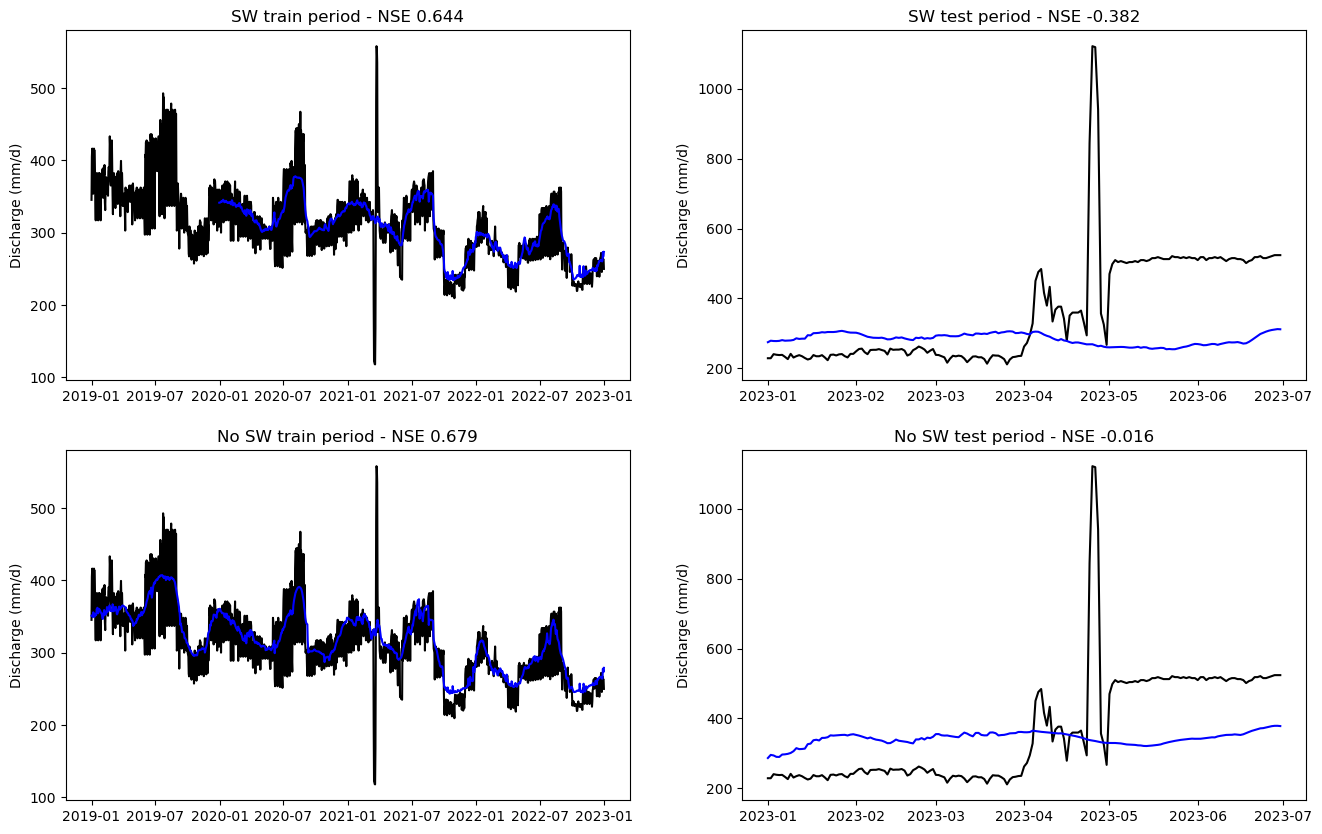

In [4]:
eval_wrapper.quick_eval(fp_no_sw='EXP00_cbr_powell_no_sw_0708_145201',
    fp_wi_sw='EXP00_cbr_powell_wi_sw_0708_145113',
    run_dir = all_runs_dir,
    basin_key = '4152450')

## EVALUATION

In [26]:
print(sw_run_dir)
eval_run(run_dir=sw_run_dir, period="test")
eval_run(run_dir=sw_run_dir, period="train")
eval_run(run_dir=sw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_cbr_powell_wi_sw_0708_145113
# Evaluation:   0%|          | 0/1 [00:00<?, ?it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4152450_glen_canyon.pkl')]


# Validation: 100%|██████████| 1/1 [00:00<00:00, 14.37it/s]


In [27]:
print(nosw_run_dir)
eval_run(run_dir=nosw_run_dir, period="test")
eval_run(run_dir=nosw_run_dir, period="train")
eval_run(run_dir=nosw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_cbr_powell_no_sw_0708_145201
# Evaluation:   0%|          | 0/1 [00:00<?, ?it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4152450_glen_canyon.pkl')]


# Validation: 100%|██████████| 1/1 [00:00<00:00, 14.37it/s]


### Load and inspect model predictions

In [28]:
with open(sw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    sw_train_results = pickle.load(fp)
    
sw_train_results.keys()

dict_keys(['4152450'])

In [29]:
with open(nosw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    nosw_train_results = pickle.load(fp)
    
nosw_train_results.keys()

dict_keys(['4152450'])

In [30]:
with open(sw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    sw_test_results = pickle.load(fp)
    
sw_test_results.keys()

dict_keys(['4152450'])

In [31]:
with open(nosw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    nosw_test_results = pickle.load(fp)
    
nosw_test_results.keys()

dict_keys(['4152450'])

In [36]:
list(nosw_test_results.keys())[0]

'4152450'

In [32]:
def plot_obs_sim_timeseries(ax, nh_dict,period=''):
    qobs = nh_dict['xr']['Q_obs']
    qsim = nh_dict['xr']['Q_sim']
    
    ax.plot(qobs['date'], qobs, c='k',label='obs')
    ax.plot(qsim['date'], qsim, c='b',label='sim')
    ax.set_ylabel("Discharge (mm/d)")
    ax.set_title(f"{period} period - NSE {nh_dict['NSE']:.3f}")
    values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))

    return values

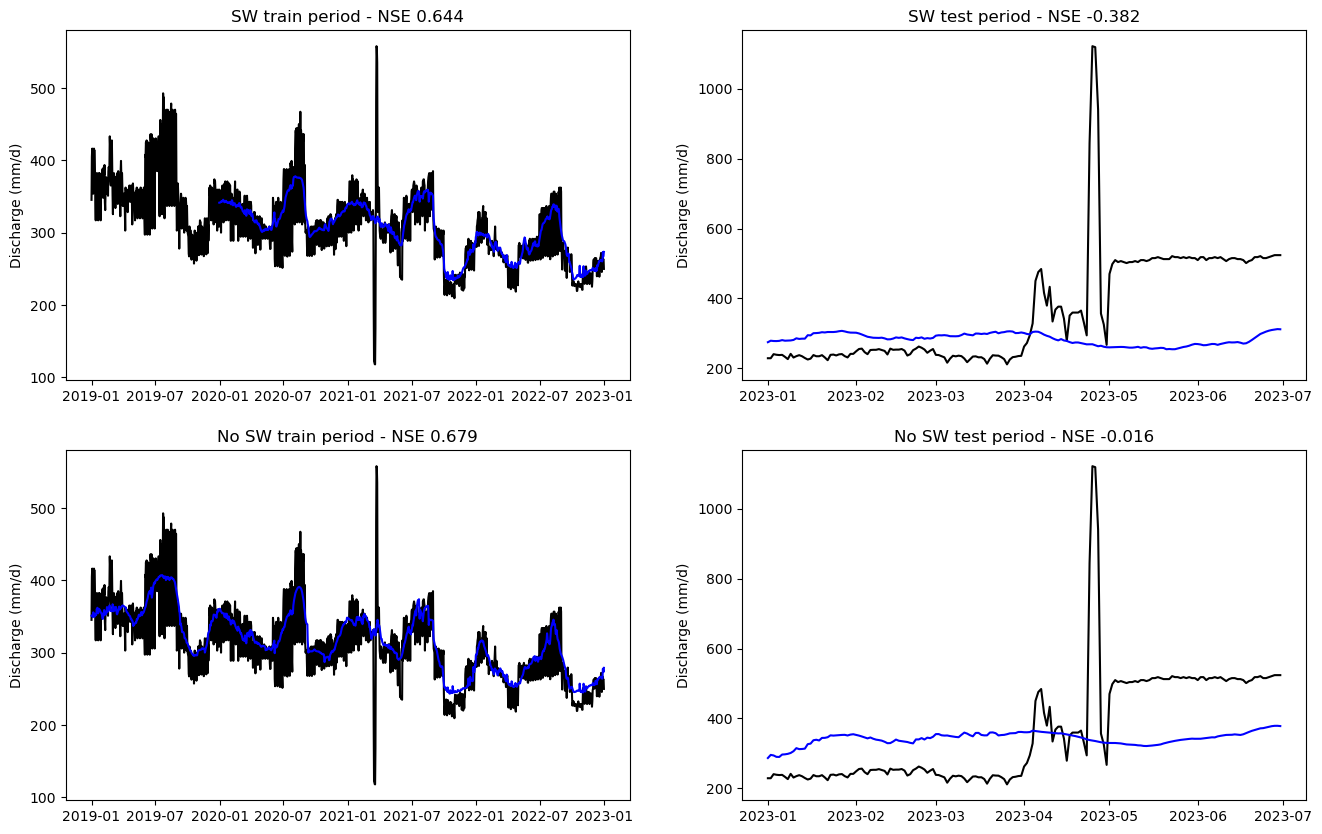

In [34]:
fig, axs = plt.subplots(2,2,figsize=(16,10))

value_dict = {}

value_dict['SW train'] = plot_obs_sim_timeseries(axs[0,0],sw_train_results['4152450']['1D'],'SW train')
value_dict['SW test'] = plot_obs_sim_timeseries(axs[0,1],sw_test_results['4152450']['1D'],'SW test')
value_dict['No SW train'] = plot_obs_sim_timeseries(axs[1,0],nosw_train_results['4152450']['1D'],'No SW train')
value_dict['No SW test'] = plot_obs_sim_timeseries(axs[1,1],nosw_test_results['4152450']['1D'],'No SW test')

metrics_df = pd.DataFrame(value_dict)